In [1]:
import os
from datetime import UTC, datetime, timedelta

import pandas as pd
from tqdm import tqdm

import wandb

# Konfiguration
CSV_PATH = "/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/test_grid_experiments_extended.csv"
WANDB_ENTITY = "roesch01-university-of-mannheim"  # Falls nötig, hier deinen Usernamen/Teamnamen eintragen
WANDB_PROJECT = "master-thesis-extended"
TAG_FILTER = "Final"

def update_csv_with_wandb_ids():
    # 1. CSV laden
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"Die Datei {CSV_PATH} wurde nicht gefunden.")
    
    df = pd.read_csv(CSV_PATH, sep=';')
    
    # Spalte für ID vorbereiten, falls noch nicht da
    if 'wandb_run_id' not in df.columns:
        df['wandb_run_id'] = None

    # 2. W&B API initialisieren
    api = wandb.Api()

    print(f"Starte Abgleich für {len(df)} Zeilen...")

    two_days_ago = datetime.now(UTC) - timedelta(days=2)
    two_days_ago_iso = two_days_ago.isoformat()


    # 3. Iteration mit Fortschrittsbalken
    pbar = tqdm(df.iterrows(), total=len(df), desc="Matching Runs")
    for index, row in pbar:

        if index < 8:
            continue

        if index > 27:
            break
        
        # Filter-Kriterien aus der CSV Zeile
        # Hinweis: Wir casten lambda_epg auf float, falls es als String geladen wurde
        concept_module = str(row['concept_module_name'])
        segmentation_module = str(row['segmentation_module_name'])
        dataset = str(row['dataset'])
        unified_model = None

        segmentation_module = segmentation_module if segmentation_module != "nan" else None
        segmentation_module = segmentation_module if segmentation_module != "SegmentationHeadMultiLayer" else "SegmentationHeadUpscaledMulti"

        if segmentation_module == "None":
            unified_model = str(row['unified_name'])

        pbar.set_postfix({"concept_module": concept_module, "segmentation_module": segmentation_module, "dataset": dataset})
        
        
        # W&B Query (MongoDB Syntax)
        # Wir filtern nach Projekt, Tag und den drei spezifischen Config-Parametern
        if unified_model:
            filters = {
                "tags": {"$in": [TAG_FILTER]},
                "config.architecture.concept_module": concept_module,
                "config.dataset": dataset,
                "config.architecture.unified_model": unified_model,
                "createdAt": {"$gte": two_days_ago_iso},  # nur Runs der letzten 2 Tage
            }
        else:
            filters = {
                "tags": {"$in": [TAG_FILTER]},
                "config.architecture.concept_module": concept_module,
                "config.architecture.segmentation_module": segmentation_module,
                "config.dataset": dataset,
                "createdAt": {"$gte": two_days_ago_iso},  # nur Runs der letzten 2 Tage
            }

        runs = api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}" if WANDB_ENTITY else WANDB_PROJECT, filters=filters)
        
        run_list = list(runs)

        # 4. Validierung & Fehlerbehandlung
        if len(run_list) == 0:
            raise ValueError(
                f"FEHLER: Kein Run gefunden für:\n"
                f"concept_module: {concept_module}, segmentation_module: {segmentation_module}, dataset: {dataset}"
            )
        
        if len(run_list) > 1:
            run_ids = [r.id for r in run_list]
            raise ValueError(
                f"FEHLER: Mehrere Runs ({len(run_list)}) gefunden für:\n"
                f"concept_module: {concept_module}, segmentation_module: {segmentation_module}, dataset: {dataset}\n"
                f"IDs: {run_ids}"
            )

        # ID eintragen
        df.at[index, 'wandb_run_id'] = run_list[0].id

    # 5. Speichern
    df.to_csv(CSV_PATH, sep=';', index=False)
    print(f"\nErfolg! Die CSV wurde aktualisiert und gespeichert unter: {CSV_PATH}")

In [2]:
update_csv_with_wandb_ids()

Starte Abgleich für 360 Zeilen...


Matching Runs:   8%|▊         | 28/360 [00:11<02:12,  2.51it/s, concept_module=SALFConceptModule, segmentation_module=None, dataset=FunnyBirds]                                        


Erfolg! Die CSV wurde aktualisiert und gespeichert unter: /pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/test_grid_experiments_extended.csv


In [11]:
# --- Setup ---

CACHE_PATH = "wandb_history_cache_extended.parquet"

METRICS = {
    "eval/recall_concepts": "Recall Concepts",
    "eval/precision_concepts": "Precision Concepts",
    "eval/total": "Total Loss",
    "eval/loss_concepts": "Concept Loss",
    "eval/iou_mean": "Mean IoU",
    "eval/foreground_dice_scores": "Foreground Dice",
    "eval/f1_concept_activations": r"Concept Activations $F_1$-Score",
    "eval/dice_mean": "Mean Dice",
    "eval/accuracy_concepts": "Concept Accuracy",
    "_runtime": "Runtime",
}

def get_data():
    if os.path.exists(CACHE_PATH) and False:
        print(f"Lade Daten aus lokalem Cache: {CACHE_PATH}")
        return pd.read_parquet(CACHE_PATH)

    print("Kein Cache gefunden. Lade von W&B...")
    df_meta = pd.read_csv(CSV_PATH, sep=';')
    api = wandb.Api()
    all_history = []

    for index, row in tqdm(df_meta.iterrows(), total=len(df_meta)):
        if pd.isna(row['wandb_run_id']): 
            continue

        if index < 8:
            continue

        if index > 27:
            break

        try:
            run = api.run(f"{WANDB_PROJECT}/{row['wandb_run_id']}")
            hist = run.history(keys=list(METRICS.keys()))
            
            if hist.empty: 
                print("empty")
                continue

            # --- EPOCH NORMALISIERUNG ---
            # Wir ignorieren den echten Step und zählen einfach hoch (1, 2, 3...)
            hist = hist.sort_index().reset_index(drop=True)
            hist['normalized_epoch'] = hist.index + 1

            # Metadaten
            hist['run_id'] = row['wandb_run_id']
            hist['concept_module'] = row['concept_module_name']
            hist['segmentation_module'] = row['segmentation_module_name']
            hist['unified_model'] = row['unified_name'] if row['unified_name'] != "nan" else None

            hist['segmentation_module'] = hist['unified_model'] if hist['unified_model'].notna().any() else hist['segmentation_module']
            
            hist['dataset'] = row['dataset']
            
            all_history.append(hist)
        except Exception as e:
            print(f"Fehler bei Run {row['wandb_run_id']}: {e}")

    full_df = pd.concat(all_history, ignore_index=True)
    full_df.to_parquet(CACHE_PATH)
    return full_df

def create_summary_table(df: pd.DataFrame):
    """Erstellt eine Tabelle mit den Bestwerten pro Run."""
    print("\nErstelle Summary Tabelle (Max-Werte)...")
    
    # Gruppieren nach Run und Metadaten, dann Maximum berechnen
    best_per_run = (
        df.loc[df.groupby("run_id")["eval/f1_concept_activations"].idxmax()]
        .reset_index(drop=True)
    )
    best_per_run['epoch'] = (best_per_run['_step'] / 781).astype(int) - 1
    
    # Spaltennamen verschönern
    # summary.columns = ['Run ID', 'Attributor', 'Level', 'Lambda', 'Max EPG', 'Max Concept F1', 'Max Label F1']

    best_per_run = best_per_run.rename(columns={
        "eval/recall_concepts": "Recall Concepts",
        "eval/precision_concepts": "Precision Concepts",
        "eval/total": "Total Loss",
        "eval/loss_concepts": "Concept Loss",
        "eval/iou_mean": "Mean IoU",
        "eval/foreground_dice_scores": "Foreground Dice",
        "eval/f1_concept_activations": r"Concept Activations $F_1$-Score",
        "eval/dice_mean": "Mean Dice",
        "eval/accuracy_concepts": "Concept Accuracy",
        "_runtime": "Runtime",
        "concept_module": "Concept Module",
        "segmentation_module": "Segmentation Module",
        "dataset": "Dataset",
    })
    
    # Speichern
    best_per_run.to_csv("experiment_summary_max_values_extended.csv", index=False, sep=';')
    print("Tabelle gespeichert unter: experiment_summary_max_values_extended.csv")
    return best_per_run

In [12]:
data = get_data()

segmentation_mapping = {
    "segdino_b": "SegDINO",
    "SegmentationHeadSETRPUP": "SETR-PUP",
    "SegmentationHeadUpscaledSingle": "Upscaled SingleLayer",
    "SegmentationHeadUpscaledMulti": "Upscaled MultiLayer",
}

concept_mapping = {
    "SegMaskAvgPool": "AvgPool",
    "SegMaskAvgPoolTrainChannelAffine": "AvgPool+Affine",
    "LogitMeanTopK": "Top-K AvgPool",
    "SegMaskMaxPool": "MaxPool",
    "SALFConceptModule": "SoftmaxWeightedPooling",
}



data["concept_module"] = data["concept_module"].replace(concept_mapping)
data["segmentation_module"] = data["segmentation_module"].replace(segmentation_mapping)

Kein Cache gefunden. Lade von W&B...


100%|██████████| 360/360 [00:20<00:00, 17.85it/s]


In [13]:
data

,_step,eval/recall_concepts,eval/precision_concepts,eval/total,eval/loss_concepts,eval/iou_mean,eval/foreground_dice_scores,eval/f1_concept_activations,eval/dice_mean,eval/accuracy_concepts,_runtime,normalized_epoch,run_id,concept_module,segmentation_module,unified_model,dataset
0,781,0.371250,0.548228,0.370713,0.370713,0.002224,0.013093,0.431236,0.003370,0.849231,1377.544837,1,e2xe2ikz,AvgPool,Upscaled SingleLayer,NaN,FunnyBirds
1,1562,0.497296,0.713395,0.289137,0.289137,0.003024,0.013575,0.548456,0.004214,0.885385,2763.616281,2,e2xe2ikz,AvgPool,Upscaled SingleLayer,NaN,FunnyBirds
2,2343,0.545751,0.738600,0.245129,0.245129,0.002966,0.012954,0.591495,0.004104,0.897179,4139.825297,3,e2xe2ikz,AvgPool,Upscaled SingleLayer,NaN,FunnyBirds
3,3124,0.587406,0.781763,0.226728,0.226728,0.004726,0.012857,0.644061,0.005858,0.909487,5525.490478,4,e2xe2ikz,AvgPool,Upscaled SingleLayer,NaN,FunnyBirds
4,3906,0.577142,0.797471,0.213199,0.213199,0.005214,0.012671,0.644202,0.006330,0.913846,6911.213696,5,e2xe2ikz,AvgPool,Upscaled SingleLayer,NaN,FunnyBirds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,16406,0.982696,0.986599,0.015538,0.015538,0.817906,0.071257,0.984070,0.823928,0.995641,20816.466906,21,dstfi0h2,SoftmaxWeightedPooling,SegDINO,segdino_b,FunnyBirds
496,17187,0.984166,0.986381,0.023002,0.023002,0.817559,0.062467,0.984608,0.822931,0.995897,21800.181951,22,dstfi0h2,SoftmaxWeightedPooling,SegDINO,segdino_b,FunnyBirds
497,17968,0.985503,0.986899,0.015096,0.015096,0.816979,0.056978,0.985621,0.821908,0.995897,22791.609041,23,dstfi0h2,SoftmaxWeightedPooling,SegDINO,segdino_b,FunnyBirds
498,18749,0.984629,0.988107,0.022027,0.022027,0.817917,0.056368,0.985879,0.822779,0.995897,23779.866448,24,dstfi0h2,SoftmaxWeightedPooling,SegDINO,segdino_b,FunnyBirds


In [14]:
summary = create_summary_table(data)


Erstelle Summary Tabelle (Max-Werte)...
Tabelle gespeichert unter: experiment_summary_max_values_extended.csv


In [20]:
for i, row in summary.iterrows():
    # print(f"Run ID: {row['run_id']}, epoch: {row['epoch']}")
    print(f"cp cbm_anyup_dinov3_funnybirds_run_{row['run_id']}_epoch{row['epoch']}.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/")


cp cbm_anyup_dinov3_funnybirds_run_3vardl0g_epoch16.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_anyup_dinov3_funnybirds_run_48x2ek26_epoch12.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_anyup_dinov3_funnybirds_run_652znd0o_epoch24.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_anyup_dinov3_funnybirds_run_8s5i66xe_epoch18.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_anyup_dinov3_funnybirds_run_d8oxb1yg_epoch24.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_anyup_dinov3_funnybirds_run_dstfi0h2_epoch14.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_anyup_dinov3_funnybirds_run_dwxi34vh_epoch23.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_anyup_dinov3_funnybirds_run_e2xe2ikz_epoch21.pth /pfs/work8/workspace/ffhk/scratch/ma_faroesch-master-thesis-shared/
cp cbm_a

In [131]:
cols = [
    "Concept Module",
    "Segmentation Module",
    "Recall Concepts",
    "Precision Concepts",
    "Concept Loss",
    "Mean IoU",
    "Foreground Dice",
    r"Concept Activations $F_1$-Score",
    "Mean Dice",
    "Concept Accuracy",
    "Runtime",
    #"dataset",
]

table = summary[cols].copy().sort_values("Concept Module")


latex_table = table.to_latex(
    index=False,
    float_format="%.3f",
    caption="Segmentation performance on FunnyBirds.",
    label="tab:segmentation_results",
)
print(latex_table)

\begin{table}
\caption{Segmentation performance on FunnyBirds.}
\label{tab:segmentation_results}
\begin{tabular}{llrrrrrrrrr}
\toprule
Concept Module & Segmentation Module & Recall Concepts & Precision Concepts & Concept Loss & Mean IoU & Foreground Dice & Concept Activations $F_1$-Score & Mean Dice & Concept Accuracy & Runtime \\
\midrule
AvgPool & SegDINO & 0.986 & 0.983 & 0.017 & 0.809 & 0.010 & 0.984 & 0.810 & 0.996 & 10980.165 \\
AvgPool & Upscaled MultiLayer & 0.946 & 0.944 & 0.037 & 0.701 & 0.010 & 0.942 & 0.701 & 0.985 & 36197.030 \\
AvgPool & Upscaled SingleLayer & 0.646 & 0.855 & 0.170 & 0.012 & 0.012 & 0.708 & 0.013 & 0.932 & 24876.500 \\
AvgPool & SETR-PUP & 0.901 & 0.960 & 0.046 & 0.779 & 0.010 & 0.924 & 0.780 & 0.981 & 8952.095 \\
AvgPool+Affine & Upscaled MultiLayer & 0.949 & 0.943 & 0.036 & 0.665 & 0.010 & 0.943 & 0.666 & 0.986 & 36328.295 \\
AvgPool+Affine & SegDINO & 0.983 & 0.988 & 0.018 & 0.811 & 0.010 & 0.985 & 0.812 & 0.996 & 11336.967 \\
AvgPool+Affine & Upscaled

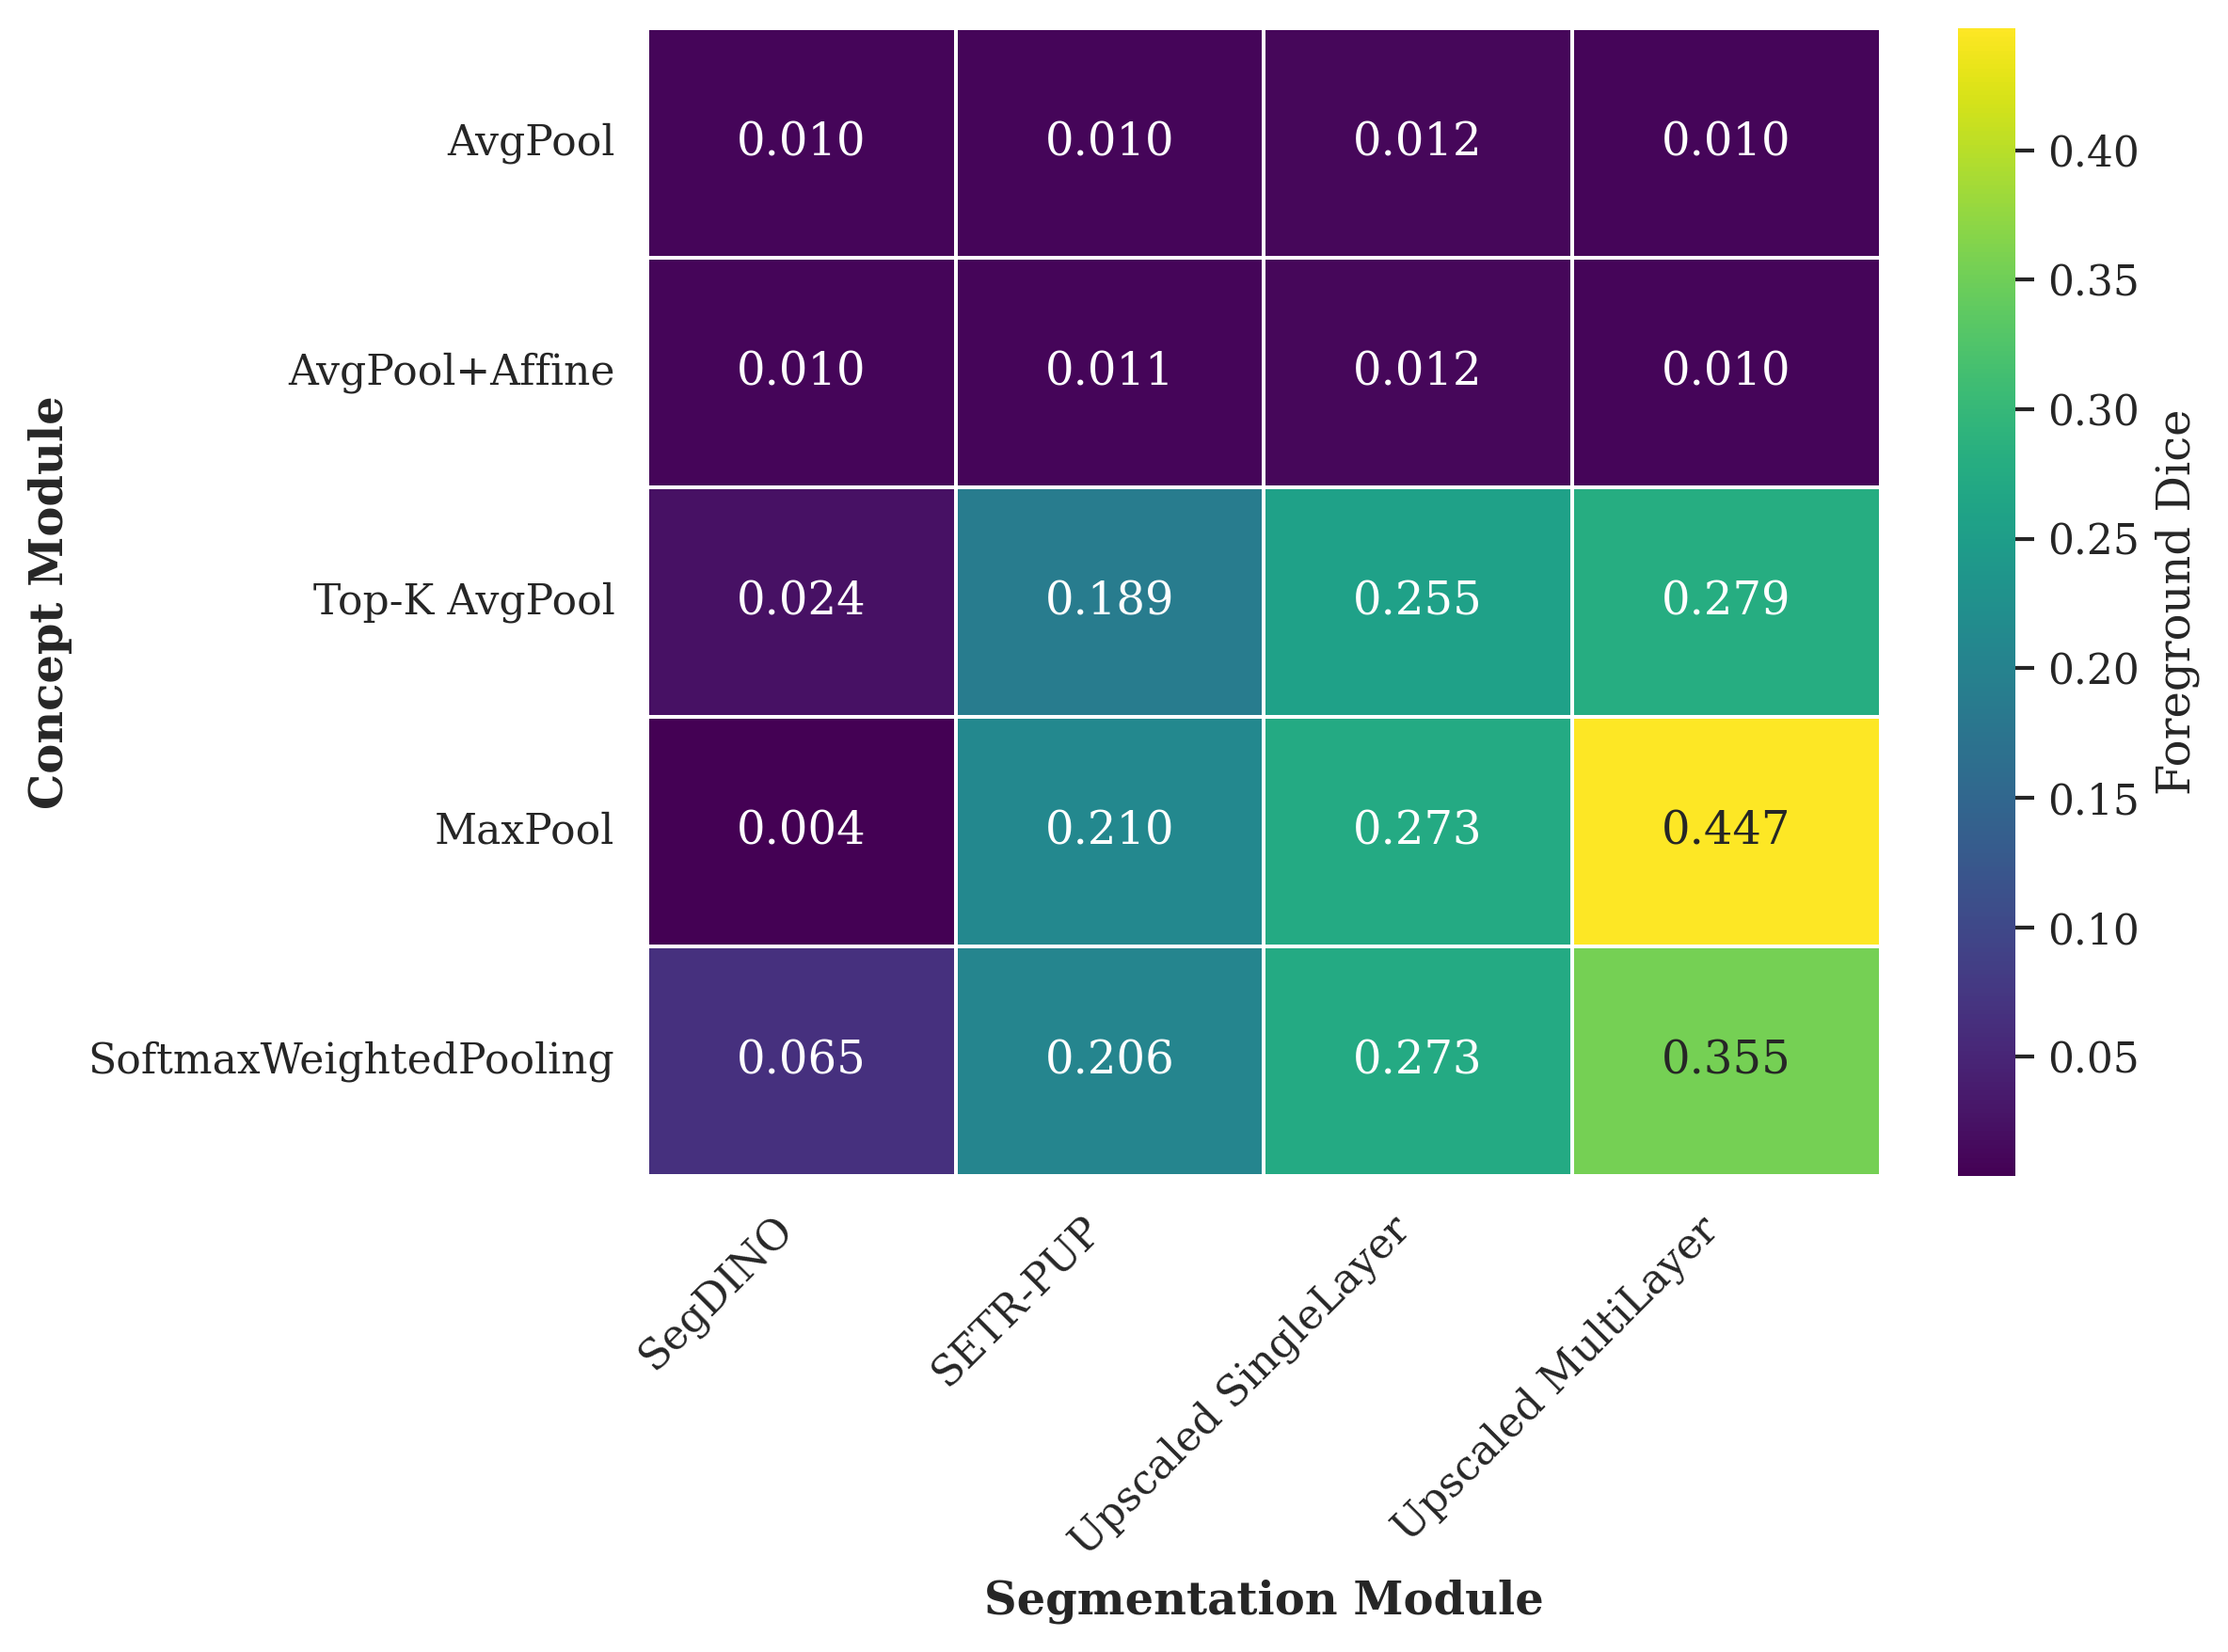

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_heatmap_paper(df, metric="eval/dice_mean", row_order=None, col_order=None, save=False):
    """
    Erstellt eine publikationsreife Heatmap.
    - row_order: Liste der 'Concept Module' in der gewünschten Reihenfolge
    - col_order: Liste der 'Segmentation Module' in der gewünschten Reihenfolge
    """
    
    # 1. Pivot Table erstellen
    pivot_table = df.pivot_table(
        index="Concept Module",
        columns="Segmentation Module",
        values=metric,
        aggfunc="mean"
    )
    
    # 2. Reihenfolge erzwingen (falls angegeben)
    if row_order:
        pivot_table = pivot_table.reindex(row_order)
    if col_order:
        pivot_table = pivot_table.reindex(columns=col_order)

    # 3. Style-Einstellungen für Paper
    sns.set_context("paper", font_scale=1.2)
    plt.figure(figsize=(8, 6), dpi=300) # Hohe DPI für den Druck
    
    # 4. Heatmap erstellen
    # cmap "viridis" oder "magma" sind wahrnehmungsgenau und druckfreundlich
    # "YlGnBu" (Yellow-Green-Blue) ist ein Klassiker für Paper
    ax = sns.heatmap(
        pivot_table, 
        annot=True, 
        fmt=".3f", 
        cmap="viridis", 
        linewidths=.5, 
        cbar_kws={'label': metric.replace('eval/', '').replace('_', ' ').title()}
    )
    
    # 5. Beschriftungen verfeinern
    ax.set_xlabel("Segmentation Module", fontweight='bold')
    ax.set_ylabel("Concept Module", fontweight='bold')
    
    # Rotation der X-Labels, damit sie nicht überlappen
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    if save:
        plt.savefig(f"heatmap_{metric}.pdf", dpi=300, bbox_inches='tight')

    plt.show()

# Beispiel für den Aufruf mit Wunsch-Reihenfolge:
my_rows = concept_mapping.values()  # ["Module_C", "Module_A", "Module_B"]
my_cols = segmentation_mapping.values()  # ["Seg_2", "Seg_1"]
plot_heatmap_paper(summary, metric="Foreground Dice", row_order=my_rows, col_order=my_cols, save=True)

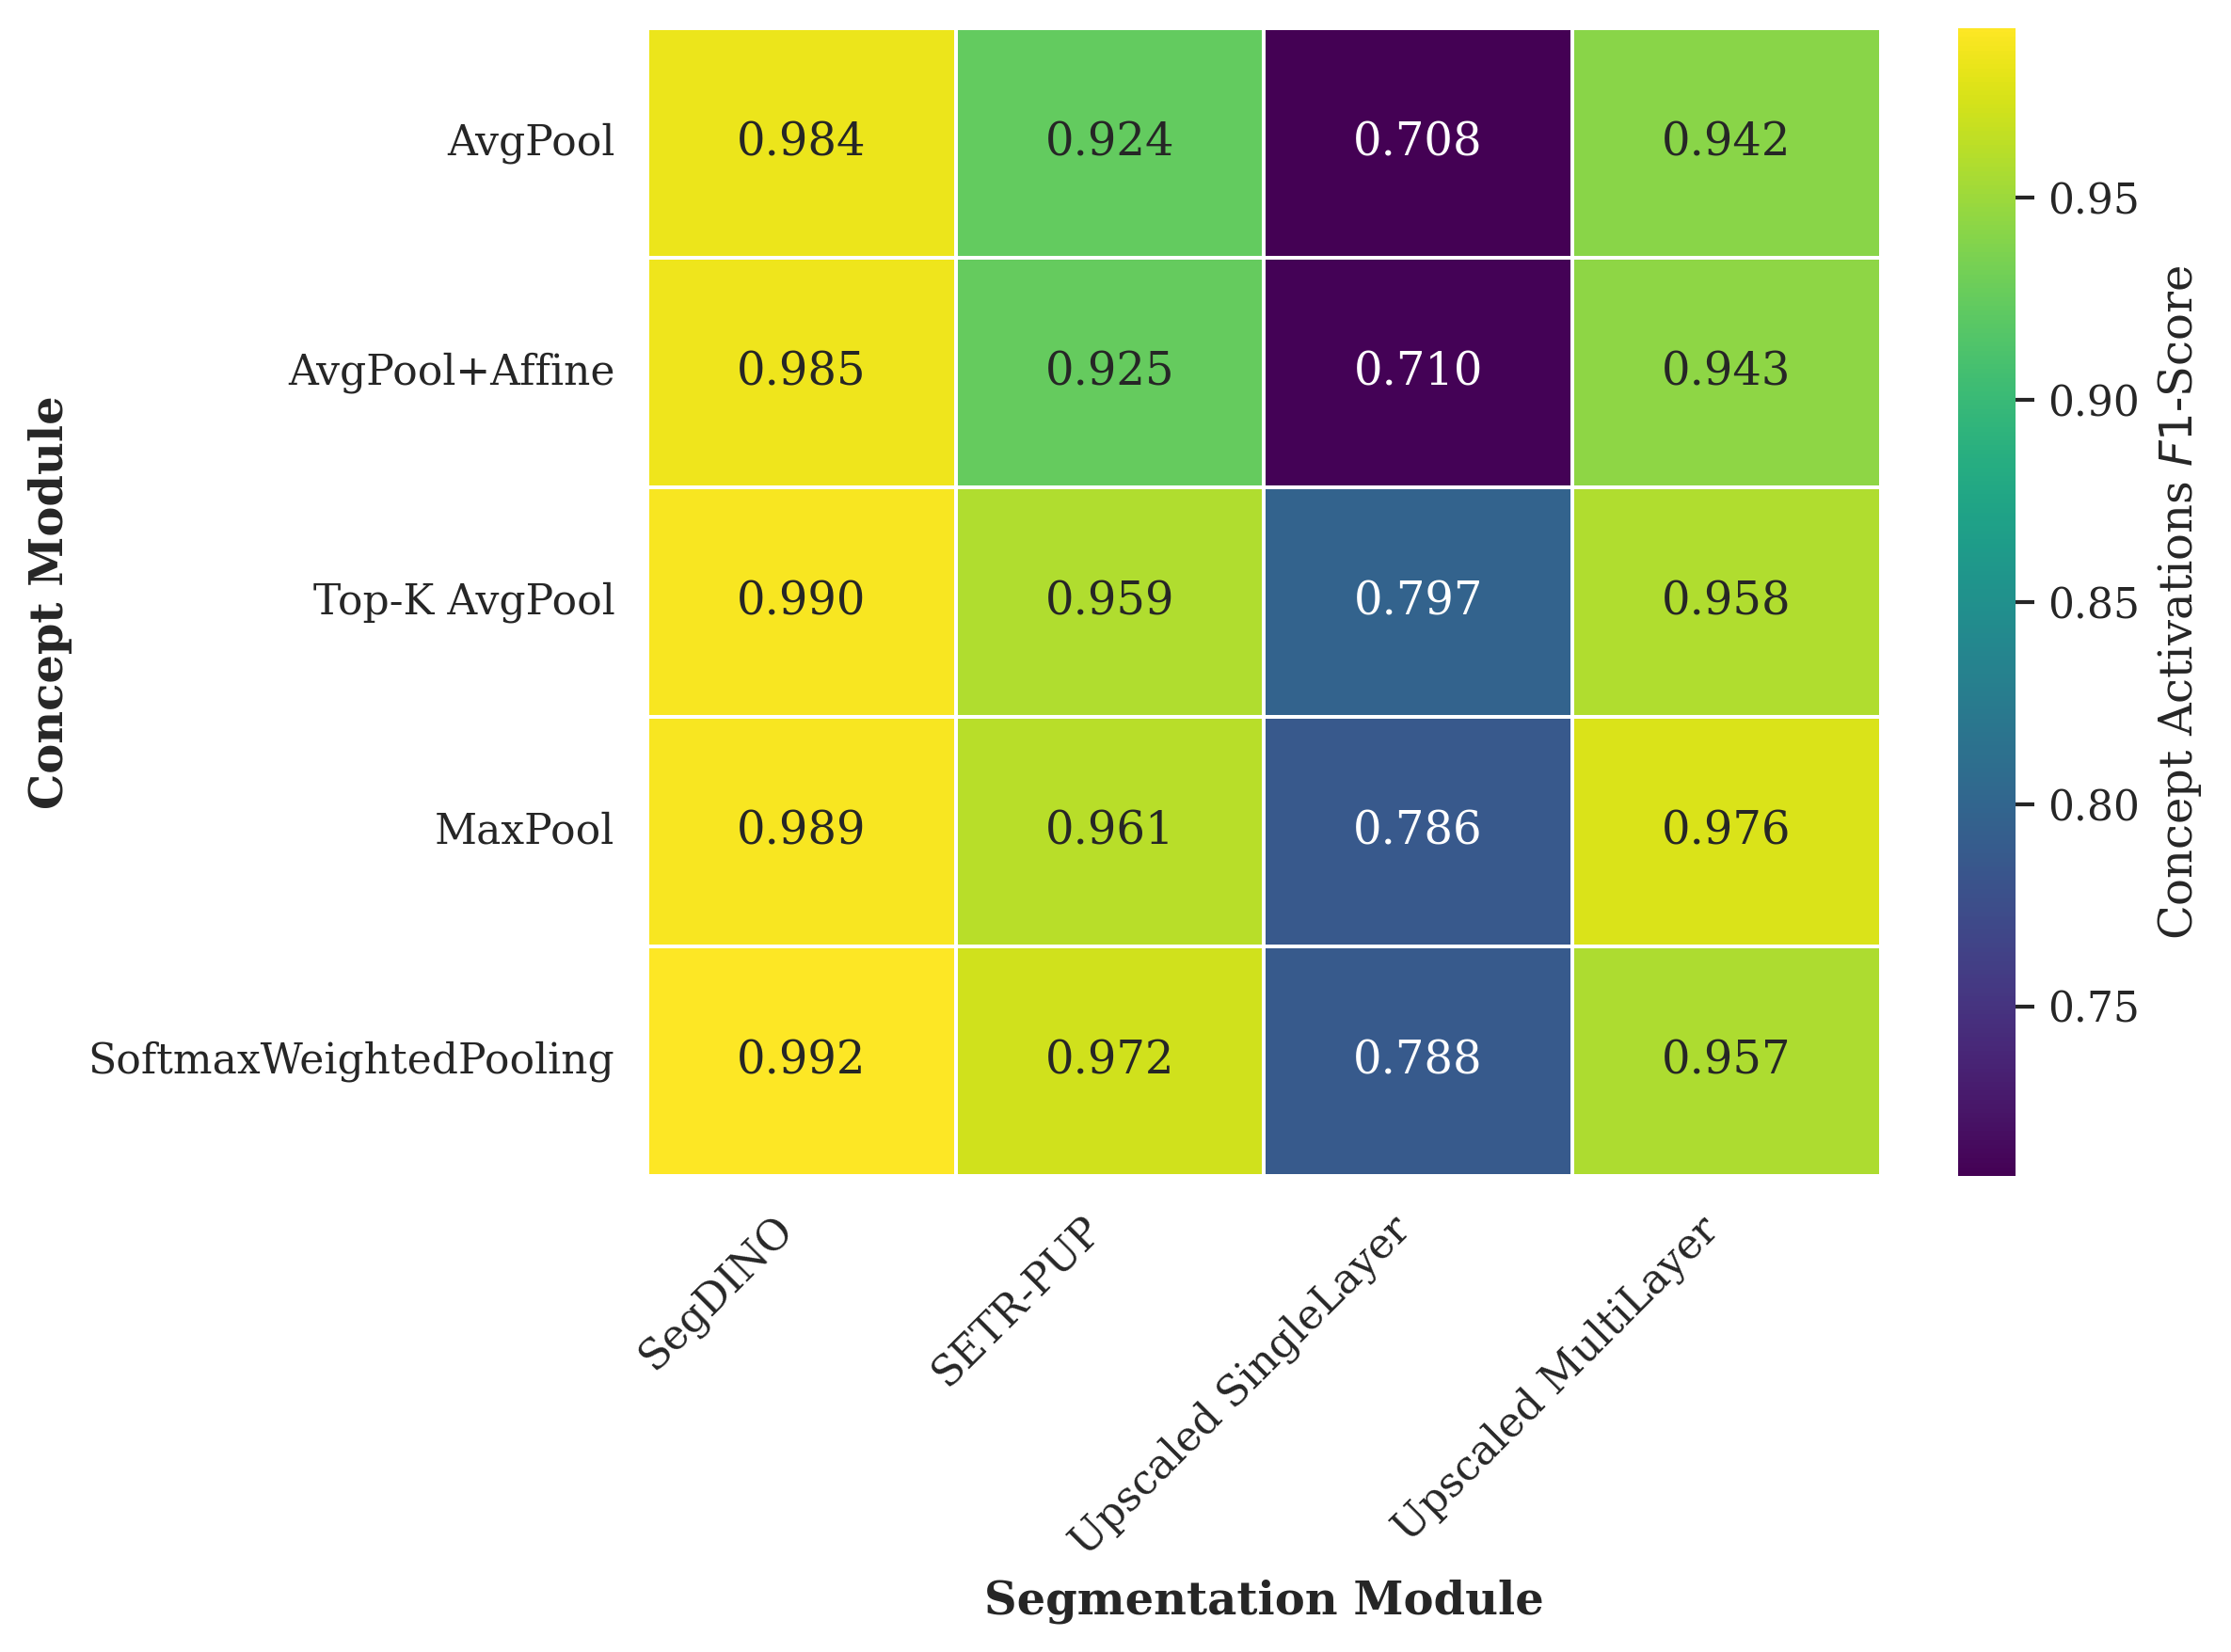

In [145]:
plot_heatmap_paper(summary, metric=r"Concept Activations $F_1$-Score", row_order=my_rows, col_order=my_cols, save=True)

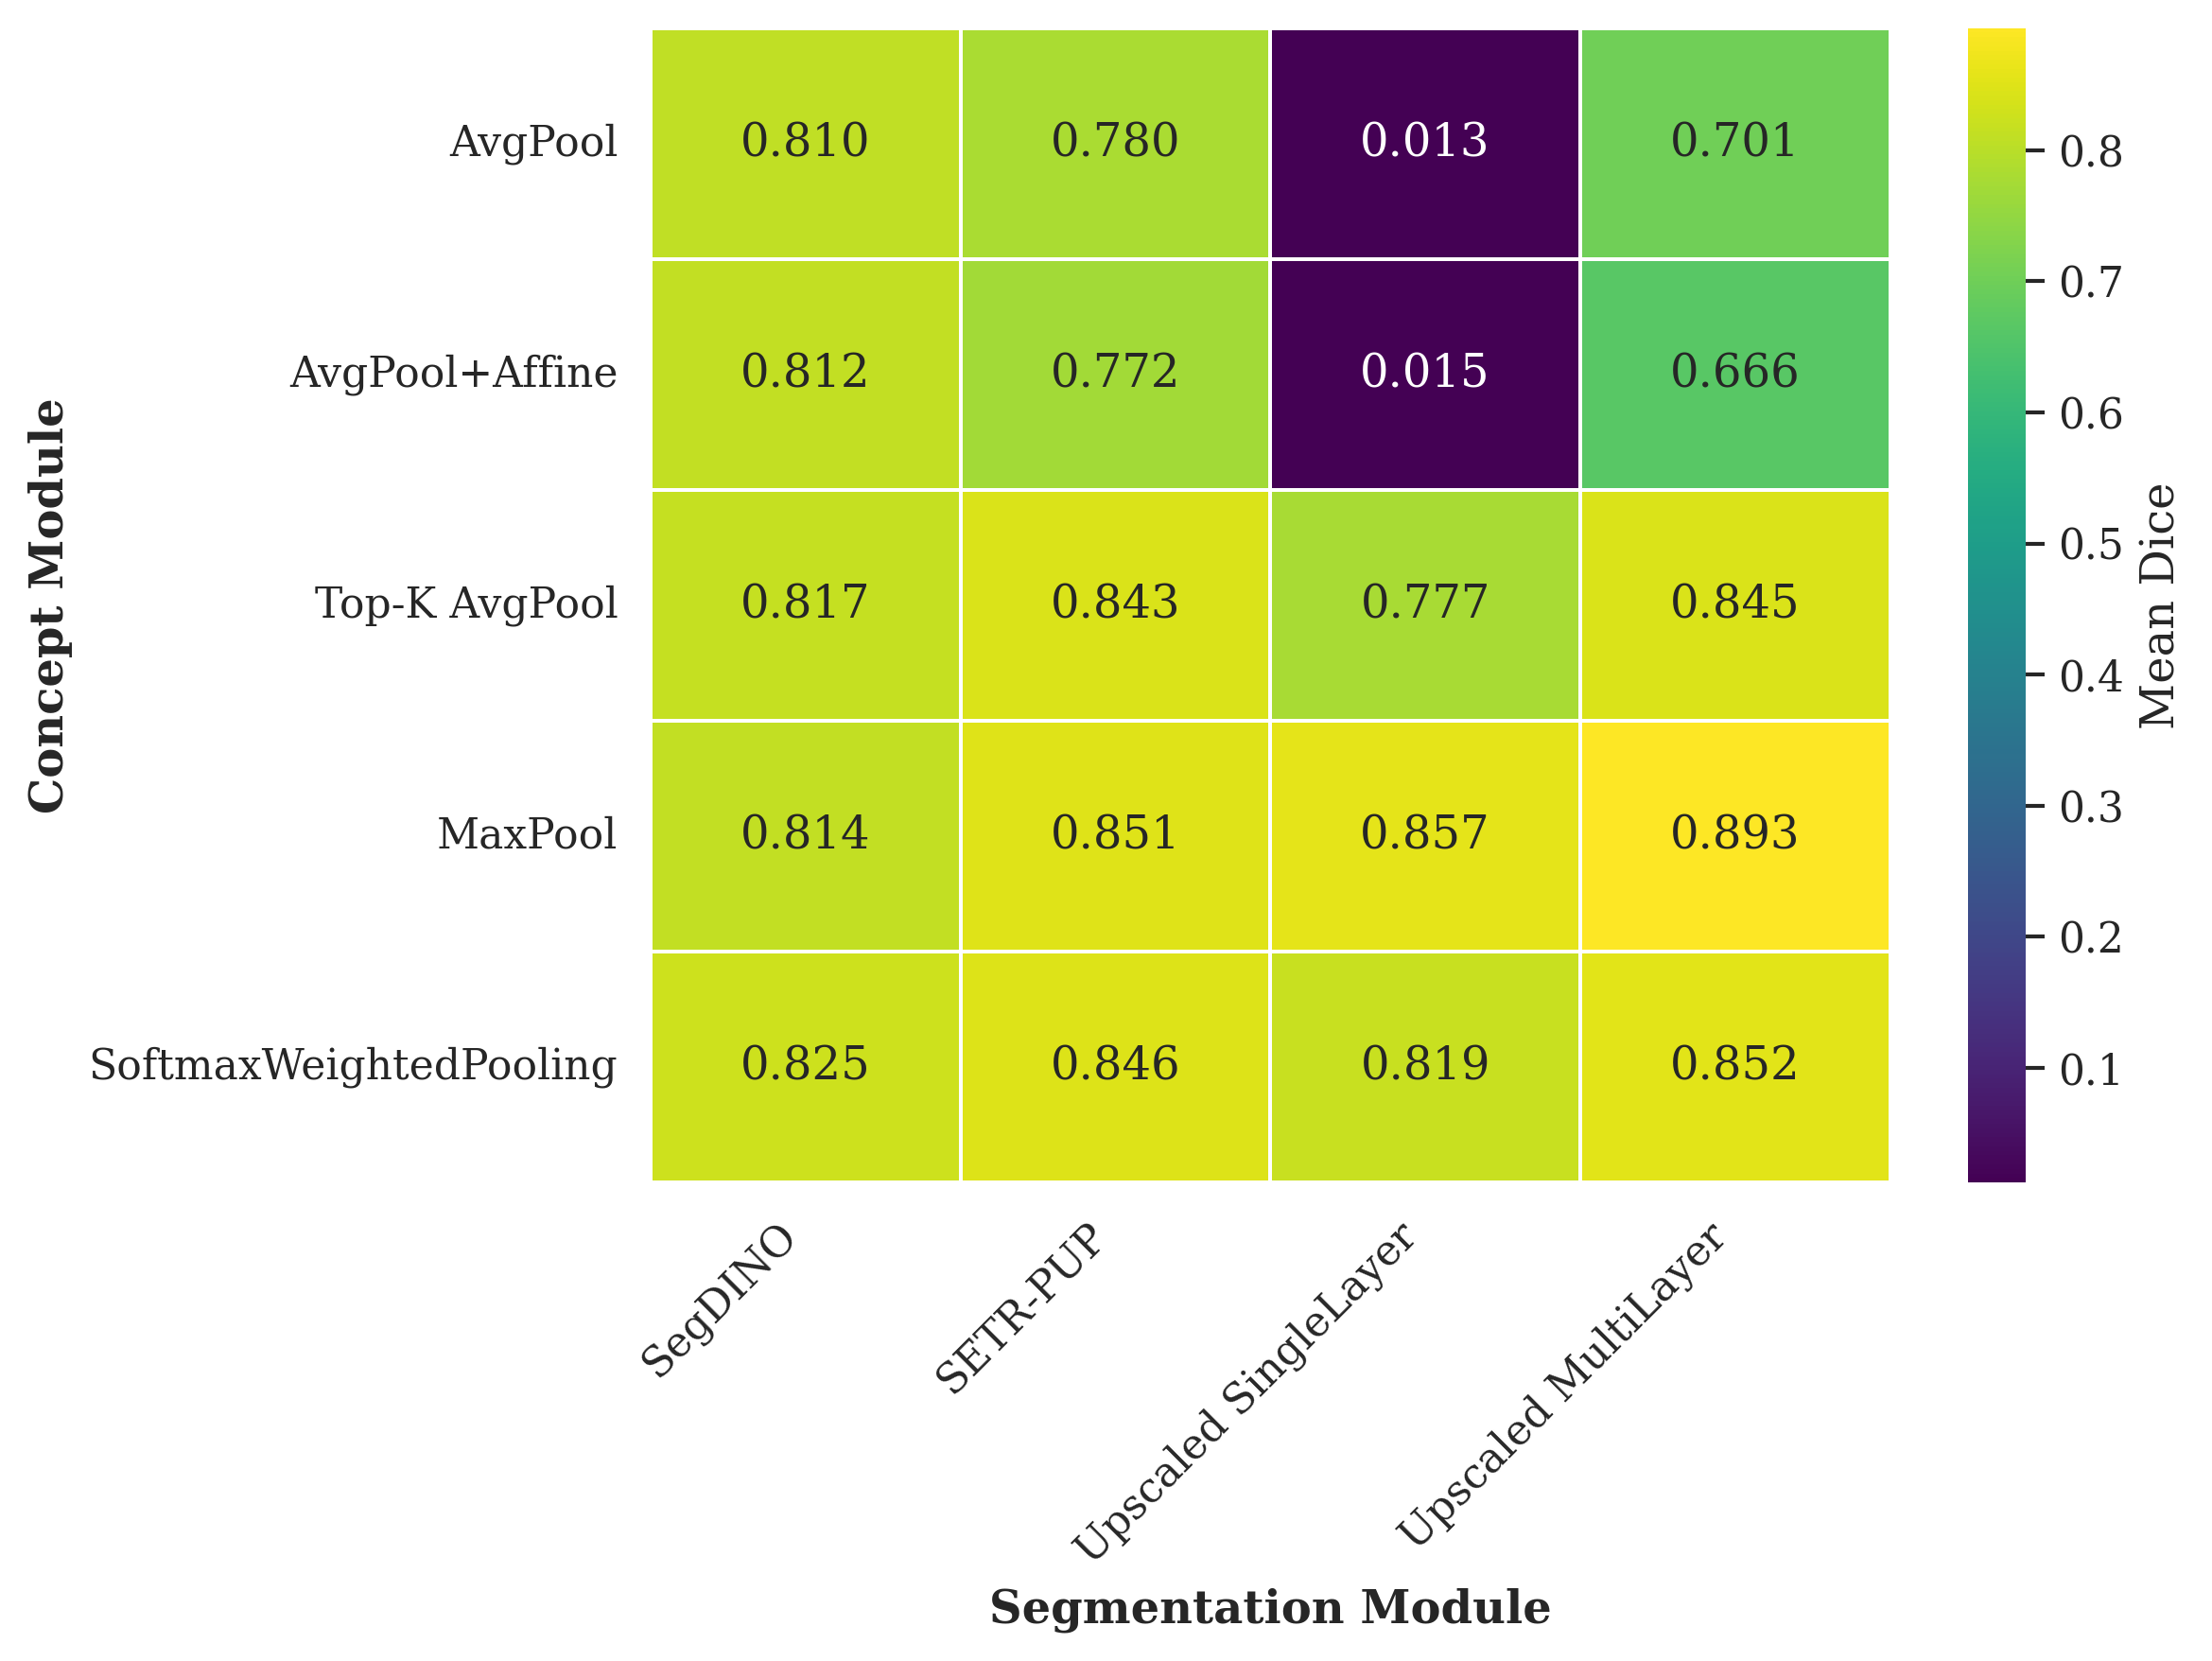

In [146]:
plot_heatmap_paper(summary, metric="Mean Dice", row_order=my_rows, col_order=my_cols, save=True)

# Segmentation Heads

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import wandb


def plot_segmentation_metric_comparison(
    *,
    run_config: dict,
    metrics: dict,
    api: wandb.Api,
    step_key: str = "_step",
    figsize=(10, 3.5),
    save_path: str | None = None,
    dpi: int = 300,
):
    """
    Plots multiple segmentation metrics (e.g. IoU, Dice) over epochs
    for a set of WandB runs.

    Parameters
    ----------
    run_config : dict
        Mapping {run_path: display_name}
    metrics : dict
        Mapping {metric_key: display_name}
    api : wandb.Api
        Initialized WandB API instance
    step_key : str
        Step key used by WandB (default: "_step")
    figsize : tuple
        Figure size
    save_path : str | None
        Base path without extension (optional)
    dpi : int
        DPI for PNG export
    """

    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize, sharex=True)

    if n_metrics == 1:
        axes = [axes]

    colors = plt.cm.tab10.colors

    print("Lade Daten von WandB...")

    for i, (run_path, display_name) in enumerate(run_config.items()):
        try:
            run = api.run(run_path)

            keys = [step_key] + list(metrics.keys())
            history = run.history(keys=keys).dropna()

            if len(history) == 0:
                continue

            epochs = np.arange(1, len(history) + 1)

            for ax, (metric_id, metric_name) in zip(axes, metrics.items()):
                ax.plot(
                    epochs,
                    history[metric_id].to_numpy(),
                    label=display_name,
                    color=colors[i % len(colors)],
                )
                ax.set_ylabel(metric_name)
                ax.set_xlabel("Epoch")
                ax.grid(True, linestyle="--")

        except Exception as e:
            print(f"Fehler bei {run_path}: {e}")

    # Gemeinsame Legende
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(run_config),
        frameon=False,
        fontsize=9,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)

    if save_path is not None:
        plt.savefig(f"{save_path}.pdf", bbox_inches="tight")
        plt.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")

    plt.show()

In [2]:
import pandas as pd

api = wandb.Api()



def collect_max_metrics_per_run(
    *,
    run_config: dict,
    metrics: dict,
    api: wandb.Api,
    step_key: str = "_step",
):
    """
    Collects the maximum value of given metrics for each WandB run.

    Parameters
    ----------
    run_config : dict
        Mapping {run_path: display_name}
    metrics : dict
        Mapping {metric_key: display_name}
    api : wandb.Api
        Initialized WandB API instance
    step_key : str
        Step key used by WandB

    Returns
    -------
    pd.DataFrame
        One row per run with max metric values
    """

    records = []

    for run_path, display_name in run_config.items():
        try:
            run = api.run(run_path)

            keys = [step_key] + list(metrics.keys())
            history = run.history(keys=keys).dropna()

            if len(history) == 0:
                continue

            record = {
                "run_name": display_name,
                "run_path": run_path,
            }

            for metric_key, metric_label in metrics.items():
                record[f"max_{metric_label.lower().replace(' ', '_')}"] = (
                    history[metric_key].max()
                )

            records.append(record)

        except Exception as e:
            print(f"Fehler bei {run_path}: {e}")

    return pd.DataFrame(records)


### FunnyBirds

Lade Daten von WandB...


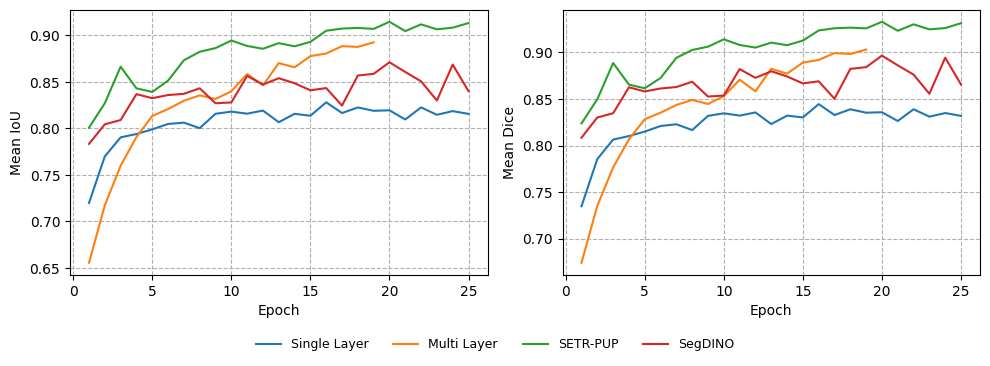

In [25]:
import matplotlib.pyplot as plt
import numpy as np

import wandb

# =========================
# CONFIG & STYLE
# =========================
RUN_CONFIG = {
    "roesch01-university-of-mannheim/master-thesis-extended/i6n2g0yg": "Single Layer",
    "roesch01-university-of-mannheim/master-thesis-extended/c01q4i6o": "Multi Layer",
    "roesch01-university-of-mannheim/master-thesis-extended/xlp9yh1g": "SETR-PUP",
    "roesch01-university-of-mannheim/master-thesis-extended/1jpajf8d": "SegDINO"
}






METRICS = {
    "eval/iou_mean": "Mean IoU",
    "eval/dice_mean": "Mean Dice"
}

plot_segmentation_metric_comparison(
    run_config=RUN_CONFIG,
    metrics=METRICS,
    api=api,
    save_path="segmentation_comparison_metrics_funnybirds",
)

In [26]:
df_max_metrics_funnybirds = collect_max_metrics_per_run(
    run_config=RUN_CONFIG,
    metrics=METRICS,
    api=api,
)

df_max_metrics_funnybirds

,run_name,run_path,max_mean_iou,max_mean_dice
0,Single Layer,roesch01-university-of-mannheim/master-thesis-...,0.828143,0.844422
1,Multi Layer,roesch01-university-of-mannheim/master-thesis-...,0.892636,0.902960
2,SETR-PUP,roesch01-university-of-mannheim/master-thesis-...,0.914727,0.932751
3,SegDINO,roesch01-university-of-mannheim/master-thesis-...,0.871203,0.896478


### CUB_112

In [27]:
RUN_CONFIG = {
    "roesch01-university-of-mannheim/master-thesis-extended/5bhtbcxc": "Single Layer", 
    "roesch01-university-of-mannheim/master-thesis-extended/av3igr7l": "Multi Layer", 
    "roesch01-university-of-mannheim/master-thesis-extended/q0gevqso": "SETR-PUP", 
    "roesch01-university-of-mannheim/master-thesis-extended/pbvhti5j": "SegDINO"
}


METRICS = {
    "eval/iou_mean": "Mean IoU", 
    "eval/dice_mean": "Mean Dice"
}

Lade Daten von WandB...


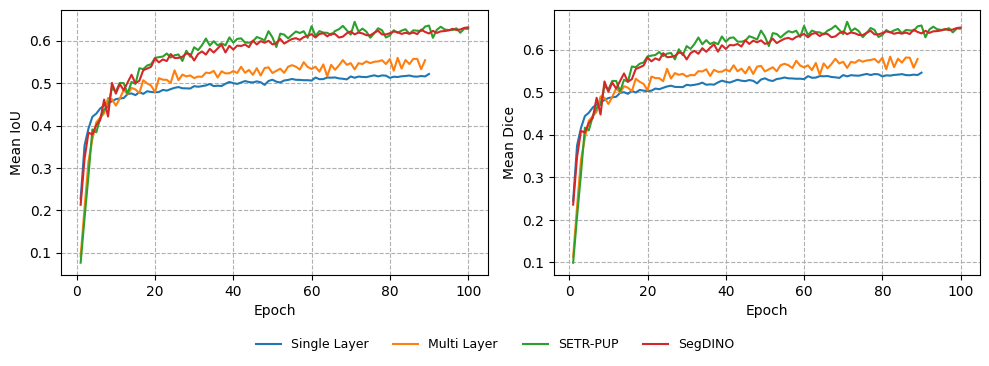

In [28]:
plot_segmentation_metric_comparison(
    run_config=RUN_CONFIG,
    metrics=METRICS,
    api=api,
    save_path="segmentation_comparison_metrics_cub112",
)


In [29]:
df_max_metrics_cub = collect_max_metrics_per_run(
    run_config=RUN_CONFIG,
    metrics=METRICS,
    api=api,
)

df_max_metrics_cub


,run_name,run_path,max_mean_iou,max_mean_dice
0,Single Layer,roesch01-university-of-mannheim/master-thesis-...,0.521496,0.545748
1,Multi Layer,roesch01-university-of-mannheim/master-thesis-...,0.559556,0.583476
2,SETR-PUP,roesch01-university-of-mannheim/master-thesis-...,0.644646,0.665252
3,SegDINO,roesch01-university-of-mannheim/master-thesis-...,0.631517,0.651769


## Merging Tables

In [30]:
df_cub = (
    df_max_metrics_cub
    .drop(columns=["run_path"], errors="ignore")
    .rename(columns={
        "max_mean_dice": "dice_cub",
        "max_mean_iou": "iou_cub",
    })
)

df_funny = (
    df_max_metrics_funnybirds
    .drop(columns=["run_path"], errors="ignore")
    .rename(columns={
        "max_mean_dice": "dice_funnybirds",
        "max_mean_iou": "iou_funnybirds",
    })
)

df_comparison = (
    df_cub
    .merge(df_funny, on="run_name", how="outer")
    .sort_values("run_name")
    .reset_index(drop=True)
)

df_comparison = df_comparison[
    [
        "run_name",
        "dice_cub",
        "iou_cub",
        "dice_funnybirds",
        "iou_funnybirds",
    ]
]

df_comparison


,run_name,dice_cub,iou_cub,dice_funnybirds,iou_funnybirds
0,Multi Layer,0.583476,0.559556,0.902960,0.892636
1,SETR-PUP,0.665252,0.644646,0.932751,0.914727
2,SegDINO,0.651769,0.631517,0.896478,0.871203
3,Single Layer,0.545748,0.521496,0.844422,0.828143


## Counting Parameters

In [9]:
import sys

sys.path.append('/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis')

import torch


def count_parameters(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

In [20]:
from architecture.segmentation_modules import ResBlock, get_segmentation_module_by_name
from architecture.segmentation_modules import __all__ as MODULE_NAMES
from architecture.unified_models import DPT


In [24]:
n_concepts = 26

for module_name in MODULE_NAMES:
    module = get_segmentation_module_by_name(module_name, feature_dim=768, n_concepts=n_concepts)
    n_params = count_parameters(module)
    print(f"{module_name}: \t{n_params:,} parameters")

class Temp:
    embed_dim=768

model = DPT(backbone=Temp(), nclass=n_concepts)
n_params = count_parameters(model)
print(f"SegDINO: \t{n_params:,} parameters")

SegmentationHeadUpscaledSingle: 	19,994 parameters
SegmentationHeadUpscaledMulti: 	4,831,898 parameters
SegmentationHeadSETRPUP: 	10,636,314 parameters
SegDINO: 	2,779,578 parameters


In [12]:
module = ResBlock(384)

n_params = count_parameters(module)
print(f"ResBlock: \t{n_params:,} parameters")

ResBlock: 	2,656,512 parameters


In [ ]:
module = get_segmentation_module_by_name('SegmentationHeadRefinement', feature_dim=768, n_concepts=26)

for name, module in module.named_modules():
    if len(list(module.parameters())) > 0:
        n = sum(p.numel() for p in module.parameters())
        print(f"{name:40s}: {n:,}")


                                        : 3,224,905
raw_head                                : 2,158,842
raw_head.net                            : 2,158,842
raw_head.net.0                          : 1,769,728
raw_head.net.1                          : 512
raw_head.net.3                          : 295,040
raw_head.net.4                          : 256
raw_head.net.6                          : 73,792
raw_head.net.7                          : 128
raw_head.net.9                          : 18,464
raw_head.net.10                         : 64
raw_head.net.12                         : 858
refine                                  : 1,066,010
refine.0                                : 914,816
refine.1                                : 256
refine.3                                : 147,584
refine.5                                : 3,354
logit_norm                              : 52


In [ ]:
module = get_segmentation_module_by_name('SegmentationHeadRefinement', feature_dim=768, n_concepts=112)

for name, module in module.named_modules():
    if len(list(module.parameters())) > 0:
        n = sum(p.numel() for p in module.parameters())
        print(f"{name:40s}: {n:,}")


                                        : 1,262,529
raw_head                                : 86,128
raw_head.net                            : 86,128
refine                                  : 1,176,176
refine.0                                : 1,013,888
refine.1                                : 256
refine.3                                : 147,584
refine.5                                : 14,448
logit_norm                              : 224
